In [24]:
%matplotlib widget

# Exploratory Data Analyis

To run this notebook first set up `config.yaml` to point to the intended source and review folders (either by editing the yaml file directly, or running `launch_annotator.bat`).

Then we can do the following:

* Check source metadata and any source annotation files load OK
* Check the source locations & plot their positions on a basemap
* Interactively select and save a basemap for the annotation notebook  

Some other things on Olly's TODO list:
* Validate data-types for the source data against the schema
* Plot class distributions of any already annotated data
* Check the class names of any annotations, 'primary_label' and 'secondary_labels' in the source data
* Compare those names against the names used in the naming schema csv file

In [25]:
import yaml
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display #, HTML
import contextily as cx
import matplotlib.pyplot as plt
from operator import attrgetter
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutureTimeoutError
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pyproj import Transformer

from anqa.annotation import FastMap, load_labels, normalize_secondary_labels
from anqa.config_editor import save_config
from anqa.get_map_regions import save_region_map

In [26]:
project_root = str(Path().resolve().parent.parent)
yaml_path = Path(project_root) / 'project' / 'config.yaml'

## 1. Validate `config.yaml`

In [27]:
use_case = {}
try:
    with open(yaml_path) as f:
        cfg = yaml.safe_load(f)

        source_dataset_path = cfg["source_dataset_path"]

        use_case = {
                'project_root': project_root,
                'source_dataset_path': source_dataset_path,
                'reviewed_data_destn': cfg["reviewed_data_destn"] or project_root + '/data/default_reviewed',
                'naming_csv': cfg["naming_csv"] or project_root + '/data/bird_names/bird_names.csv',
                'audio_folder': Path(source_dataset_path) / 'audio',
                'map_extents': cfg['map_extents'] or 'new_zealand',
                'geographic_extents': cfg['geographic_extents']
}
except Exception as e:
    print(f"Details: {e}")
    print("⚠️ There's a problem with config.yaml — A new default template will be created" \
            " you can edit this manually, or with the annotation launcher, then re-run the notebook")

    default_yaml = {
                'source_dataset_path': project_root + '/data/default_source',
                'reviewed_data_destn': project_root + '/data/default_reviewed',
                'naming_csv':  project_root + '/data/bird_names/bird_names.csv',
                'author': 'El Chupanibre',
                'reviewer': 'Alicanto',
                'map_extents': 'new_zealand',
                'geographic_extents': {'new_zealand': 
                                        {'min_longitude': 166,
                                         'max_longitude': 179,
                                         'min_latitude': -49,
                                         'max_latitude': -34}
                                        }
                }
    save_config(default_yaml)  #I'm not happy about this, let's add an explicit filepath

load_samples = False
items = [display(item) for item in use_case.items()]

('project_root', 'C:\\Users\\ollyp\\OneDrive\\Desktop\\anqa')

('source_dataset_path',
 'C:\\Users\\ollyp\\OneDrive\\Desktop\\anqa/data/default_source')

('reviewed_data_destn',
 'C:\\Users\\ollyp\\OneDrive\\Desktop\\anqa/data/default_reviewed')

('naming_csv',
 'C:\\Users\\ollyp\\OneDrive\\Desktop\\anqa/data/bird_names/bird_names.csv')

('audio_folder',
 WindowsPath('C:/Users/ollyp/OneDrive/Desktop/anqa/data/default_source/audio'))

('map_extents', 'new_zealand')

('geographic_extents',
 {'new_zealand': {'min_longitude': 166,
   'max_longitude': 179,
   'min_latitude': -49,
   'max_latitude': -34}})

In [28]:
class FilePaths:
    def __init__(self, options: dict):
        _project_dir = Path(options['project_root'])
        self.original_dataset = Path(options['source_dataset_path'])
        self.data_folder = _project_dir / 'data'
        self.audio_folder = options.get('audio_folder', self.data_folder)
        _metadata_files = [f for ext in ('csv', 'parquet') for f in self.original_dataset.glob(f'metadata.{ext}')]
        _label_files = [f for ext in ('csv', 'parquet') for f in self.original_dataset.glob(f'annotations.{ext}')]
        if len(_metadata_files) == 0:
            raise ValueError(f'No metadata.csv or metadata.parquet found in {self.original_dataset}')
        if len(_metadata_files) > 1:
            raise ValueError(f'Found both metadata.csv and metadata.parquet in {self.original_dataset} — ambiguous')
        if len(_label_files) > 1:
            raise ValueError(f'Found both metadata.csv and metadata.parquet in {self.original_dataset} — ambiguous')
        self.original_labels = _label_files[0] if len(_label_files) == 1 else None
        self.original_metadata = _metadata_files[0]
        self.out_dataset = Path(options['reviewed_data_destn'])
        self.out_dataset.mkdir(exist_ok=True, parents=True)
        self.out_labels = self.out_dataset / 'annotations.parquet'
        self.out_metadata = self.out_dataset / 'metadata.parquet'
        self.maps_dir = self.data_folder / 'basemaps'
        self.naming_csv = Path(options['naming_csv'])

paths = FilePaths(use_case)
geo_name = use_case['map_extents']
extents = use_case['geographic_extents'][geo_name]

In [29]:
extents

{'min_longitude': 166,
 'max_longitude': 179,
 'min_latitude': -49,
 'max_latitude': -34}

In [30]:
def validate_wgs84(df, lat_col='latitude', lon_col='longitude'):
    if lat_col not in df.columns or lon_col not in df.columns:
        raise ValueError(f"Missing expected columns: {lat_col!r}, {lon_col!r}")

    lat = df[lat_col]
    lon = df[lon_col]
    n = len(df)

    if n == 0:
        warnings_list = ["DataFrame is empty."]
        print(f"WARNING: {warnings_list[0]}")
        return {"valid": False, "n_valid": 0, "n_total": 0, "warnings": warnings_list}

    warnings_list = []

    lat_null = lat.isna()
    lon_null = lon.isna()

    if lat_null.all():
        warnings_list.append(f"'{lat_col}' is entirely empty (all NaN).")
    if lon_null.all():
        warnings_list.append(f"'{lon_col}' is entirely empty (all NaN).")

    n_lat_null = lat_null.sum()
    n_lon_null = lon_null.sum()
    if 0 < n_lat_null < n:
        warnings_list.append(f"'{lat_col}' has {n_lat_null} missing value(s) out of {n}.")
    if 0 < n_lon_null < n:
        warnings_list.append(f"'{lon_col}' has {n_lon_null} missing value(s) out of {n}.")

    lat_numeric = pd.to_numeric(lat, errors='coerce')
    lon_numeric = pd.to_numeric(lon, errors='coerce')

    bad_lat_dtype = lat_numeric.isna() & ~lat_null
    bad_lon_dtype = lon_numeric.isna() & ~lon_null
    if bad_lat_dtype.any():
        warnings_list.append(f"'{lat_col}' has {bad_lat_dtype.sum()} non-numeric value(s).")
    if bad_lon_dtype.any():
        warnings_list.append(f"'{lon_col}' has {bad_lon_dtype.sum()} non-numeric value(s).")

    valid_mask = lat_numeric.notna() & lon_numeric.notna()
    out_of_range_lat = valid_mask & ((lat_numeric < -90) | (lat_numeric > 90))
    out_of_range_lon = valid_mask & ((lon_numeric < -180) | (lon_numeric > 180))

    if out_of_range_lat.any():
        bad_vals = lat_numeric[out_of_range_lat].unique()[:5]
        warnings_list.append(
            f"'{lat_col}' has {out_of_range_lat.sum()} value(s) outside [-90, 90], e.g. {list(bad_vals)}."
        )
    if out_of_range_lon.any():
        bad_vals = lon_numeric[out_of_range_lon].unique()[:5]
        warnings_list.append(
            f"'{lon_col}' has {out_of_range_lon.sum()} value(s) outside [-180, 180], e.g. {list(bad_vals)}."
        )

    null_island = valid_mask & (lat_numeric == 0) & (lon_numeric == 0)
    if null_island.any():
        warnings_list.append(
            f"{null_island.sum()} row(s) have coordinates (0, 0) — "
            f"often a placeholder for missing GPS data rather than a real location."
        )

    n_valid = (valid_mask & ~out_of_range_lat & ~out_of_range_lon).sum()

    for w in warnings_list:
        print(f"WARNING: {w}")

    print(f"{n_valid}/{n} rows have valid WGS84 lat/lon values.")

    return {
        "valid": n_valid > 0 and len(warnings_list) == 0,
        "n_valid": n_valid,
        "n_total": n,
        "warnings": warnings_list,
    }


def populate_random_points(df, extents, lat_col='latitude', lon_col='longitude',
                            random_seed=None, inplace=False):
    """
    Fill lat/lon columns with random points uniformly sampled within `extents`.

    extents: dict with keys 'min_latitude', 'max_latitude', 'min_longitude', 'max_longitude'.
    inplace: if False (default), returns a modified copy; if True, mutates df directly.
    """
    required_keys = {'min_latitude', 'max_latitude', 'min_longitude', 'max_longitude'}
    missing_keys = required_keys - extents.keys()
    if missing_keys:
        raise ValueError(f"extents dict is missing key(s): {missing_keys}")

    target = df if inplace else df.copy()
    n = len(target)

    rng = np.random.default_rng(random_seed)
    target[lat_col] = rng.uniform(extents['min_latitude'], extents['max_latitude'], size=n)
    target[lon_col] = rng.uniform(extents['min_longitude'], extents['max_longitude'], size=n)

    print(f"Populated {n} row(s) with random points within extents {extents}.")

    return target

## 2. Validate the Source Metadata

In [31]:
if paths.original_metadata.suffix == '.csv':
    df_meta = pd.read_csv(paths.original_metadata)
else:
    df_meta = pd.read_parquet(paths.original_metadata)

df_meta = df_meta.sort_values(by='filename')  #Ensures all the files from one class folder are presented sequentially
df_meta['secondary_labels'] = df_meta['secondary_labels'].apply(normalize_secondary_labels)
df_meta.head(3)

,filename,collection,secondary_labels,url,latitude,longitude,author,license,recorded_on,reviewed_by,reviewed_on,source_filename,source_start_s,source_end_s,models_used
30,20190831_074504_from_0.flac,NaN,[],NaN,NaN,NaN,Sumudu,NaN,2019-08-31 07:45:04,NaN,NaN,20190831_074504.wav,0.0,60.0,NaN
32,20190831_074504_from_120.flac,NaN,[],NaN,NaN,NaN,Sumudu,NaN,2019-08-31 07:45:04,NaN,NaN,20190831_074504.wav,120.0,180.0,NaN
33,20190831_074504_from_180.flac,NaN,[],NaN,NaN,NaN,Sumudu,NaN,2019-08-31 07:45:04,NaN,NaN,20190831_074504.wav,180.0,240.0,NaN


In [32]:
#If no spatial data is found, some random points will be created for setup purposes.
results = validate_wgs84(df_meta)
results

0/45 rows have valid WGS84 lat/lon values.


{'valid': np.False_,
 'n_valid': np.int64(0),
 'n_total': 45,
 'warnings': ["'latitude' is entirely empty (all NaN).",
  "'longitude' is entirely empty (all NaN)."]}

In [33]:
extents

{'min_longitude': 166,
 'max_longitude': 179,
 'min_latitude': -49,
 'max_latitude': -34}

If there is no valid spatial data at all, let's randomly assign some for now, just so that the visualisation workflow runs

In [34]:
if results["n_valid"] == 0:
    df_meta = populate_random_points(df_meta, extents)  #, random_seed=42
    results = validate_wgs84(df_meta)
    display(results)

Populated 45 row(s) with random points within extents {'min_longitude': 166, 'max_longitude': 179, 'min_latitude': -49, 'max_latitude': -34}.
45/45 rows have valid WGS84 lat/lon values.


{'valid': True, 'n_valid': np.int64(45), 'n_total': 45, 'warnings': []}

## Chose basemap style & check sample spatial data
Let's start by taking a look at some suitable base-map styles for the annotator

In [35]:
#display(cx.providers.flatten())

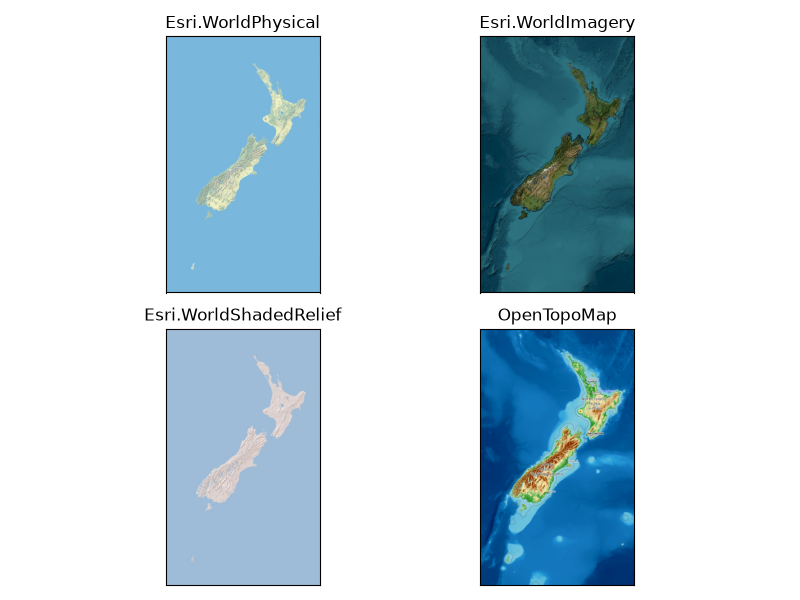

In [36]:
HARD_TIMEOUT = 20

include = ['Esri.WorldPhysical',
           #'Esri.WorldTerrain',
           'Esri.WorldImagery',
           'Esri.WorldShadedRelief',
           #'CartoDB.Positron',
           'OpenTopoMap',
           ]

xmin, ymin = extents["min_longitude"], extents["min_latitude"]
xmax, ymax = extents["max_longitude"], extents["max_latitude"]

def fetch(provider):
    return cx.bounds2img(
        xmin, ymin, xmax, ymax, source=provider, ll=True,
        n_connections=1, timeout=10,
    )

fig, axes = plt.subplots(2, len(include) // 2, figsize=(4 * len(include) // 2,6))

with ThreadPoolExecutor(max_workers=1) as pool:
    for ax, name in zip(axes.flatten(), include):
        provider = attrgetter(name)(cx.providers)
        ax.set_title(name)
        ax.set_xticks([])
        ax.set_yticks([])
        future = pool.submit(fetch, provider)
        try:
            img, extent = future.result(timeout=HARD_TIMEOUT)
            ax.imshow(img, extent=extent)
        except FutureTimeoutError:
            ax.text(0.5, 0.5, "unavailable\n(timed out)", ha="center", va="center",
                     transform=ax.transAxes, fontsize=9, color="gray")
            ax.set_facecolor("#f0f0f0")
        except Exception as e:
            ax.text(0.5, 0.5, f"unavailable\n({type(e).__name__})", ha="center", va="center",
                     transform=ax.transAxes, fontsize=9, color="gray")
            ax.set_facecolor("#f0f0f0")

plt.tight_layout()
plt.show()

Chose the desired basemap style, and plot with any available source data locations, then make any adjustment to the map extents.

In [37]:
BASEMAP_CHOICE = 'Esri.WorldImagery'
provider = attrgetter(BASEMAP_CHOICE)(cx.providers)

In [ ]:
#Visualise all the available data on the chosen basemap
def plot_points_on_basemap(df, extents, lat_col='latitude', lon_col='longitude',
                            basemap_source=None, figsize=(10, 10), point_kwargs=None):
    """
    Scatter-plot df[lat_col]/df[lon_col] over a contextily basemap, zoomed to `extents`.
    extents: dict with keys 'min_lat', 'max_lat', 'min_lon', 'max_lon' (WGS84).

    Returns (fig, ax, get_extents) — call get_extents() at any point (mid-session in a
    Jupyter widget backend, or after closing the window in script mode) to retrieve the
    current view as a WGS84 extents dict.
    """
    to_3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    to_4326 = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

    x, y = to_3857.transform(df[lon_col].values, df[lat_col].values)
    xmin, ymin = to_3857.transform(extents['min_longitude'], extents['min_latitude'])
    xmax, ymax = to_3857.transform(extents['max_longitude'], extents['max_latitude'])

    fig, ax = plt.subplots(figsize=figsize)

    default_point_kwargs = dict(s=20, c='red', alpha=0.8, edgecolor='k', linewidth=0.5, zorder=2)
    if point_kwargs:
        default_point_kwargs.update(point_kwargs)
    ax.scatter(x, y, **default_point_kwargs)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    source = basemap_source
    cx.add_basemap(ax, source=source, crs="EPSG:3857")

    ax.set_axis_off()
    plt.tight_layout()

    def get_extents():
        cur_xmin, cur_xmax = ax.get_xlim()
        cur_ymin, cur_ymax = ax.get_ylim()
        lon_min, lat_min = to_4326.transform(cur_xmin, cur_ymin)
        lon_max, lat_max = to_4326.transform(cur_xmax, cur_ymax)
        return {
            'min_latitude': lat_min, 'max_latitude': lat_max,
            'min_longitude': lon_min, 'max_longitude': lon_max,
        }

    return fig, ax, get_extents


In [39]:
%matplotlib widget

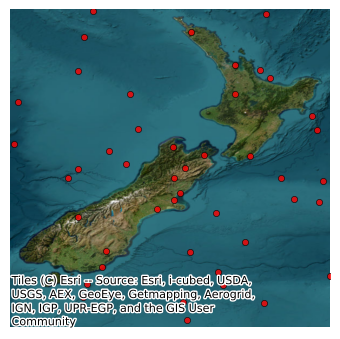

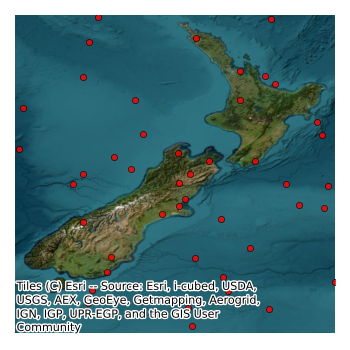

In [40]:
fig, ax, get_extents = plot_points_on_basemap(df_meta,  extents, basemap_source=provider, figsize=(3.5, 3.5))
fig
#fig  # display and interact with it

In [41]:
#extents = {'min_lat': -47.5, 'max_lat': -34.0, 'min_lon': 166.0, 'max_lon': 179.0}
#fig, ax = plot_points_on_basemap(df_meta, extents, basemap_source=provider)
#plt.show()

In [47]:
new_extents = get_extents()

In [49]:
map_path = save_region_map(geo_name, provider=provider, extents=new_extents, images_dir=paths.maps_dir)
map_path

WindowsPath('C:/Users/ollyp/OneDrive/Desktop/anqa/data/basemaps/new_zealand.png')

In [50]:
# 1. Load the saved PNG
img = mpimg.imread(map_path)
#Note the image was saved in EPSG:3857 (web-mercator)

extent_4326 = (xmin, xmax, ymin, ymax)  # fill in your saved values

# Transform WGS84 (lat/lon) points to Web Mercator to match the image
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

transformed = transformer.transform([xmin, xmax], [ymin, ymax])
extent_3857 = [transformed[0][0], transformed[0][1], 
               transformed[1][0], transformed[1][1]]
extent_3857


[18479035.471683413, 19926188.85199597, -6274861.394006575, -4028802.026134408]

In [51]:
lats = [-48, -40, -38, -36]
lons = [168, 170, 172, 174]
xs, ys = transformer.transform(lons, lats)  # note: (lon, lat) order with always_xy=True

# 4. Plot
#fig, ax = plt.subplots(figsize=(5, 5))
#ax.imshow(img, extent=extent_3857, origin="upper")
#ax.scatter(xs, ys, color="red", s=20, zorder=5)
#ax.set_xlim(extent_3857[0], extent_3857[1])
#ax.set_ylim(extent_3857[2], extent_3857[3])
#ax.set_axis_off()
#plt.show()

Start by loading the metadata dataframe, there should be exactly one metadata row per file

Check previous labels if they exists:

In [45]:
df_labels = load_labels(paths.original_labels)
df_labels.head()

,Filename,Start Time (s),End Time (s),Low Freq (Hz),High Freq (Hz),Label,Type,Sex,Score,Delta Time (s),Delta Freq (Hz),Avg Power Density (dB FS/Hz),Life Stage,Indv ID
0,20190831_083004_from_420.flac,37.6,45.0,1230.0,2365.0,weka1,<NA>,<NA>,NaN,7.4,1135.0,-53.0,<NA>,<NA>
1,20190831_181504_from_240.flac,54.5,60.0,997.0,2656.0,weka1,<NA>,<NA>,NaN,5.5,1659.0,-62.1,<NA>,<NA>
2,20190831_181504_from_300.flac,0.0,5.1,997.0,2656.0,weka1,<NA>,<NA>,NaN,5.1,1659.0,-61.2,<NA>,<NA>
3,20190831_181504_from_300.flac,10.3,37.8,1133.0,2655.0,weka1,<NA>,<NA>,NaN,27.5,1522.0,-62.2,<NA>,<NA>
4,20190831_181504_from_780.flac,13.4,49.5,444.0,8302.0,weka1,<NA>,<NA>,NaN,36.1,7858.0,-45.6,<NA>,<NA>


Check the naming schema

In [46]:
df_naming = pd.read_csv(paths.naming_csv)
df_naming.head()

,CommonName,eBird,ScientificName,ClassifyName,AnnotationGroup,OrderName
0,Northern Royal Albatross,norroal,Diomedea sanfordi,Northern Royal Albatross,Birds,Albatross
1,Bellbird,nezbel1,Anthornis melanura,Bellbird,Birds,Bellbird
2,Bellbird or Tui,bellbird_tui,Anthornis melanura or Prosthemadera novaeseela...,Bellbird-Tui,Fallback,Bellbird
3,Bird,bird,Aves,Bird,Fallback,Bird
4,Australasian Bittern,ausbit1,Botaurus poiciloptilus,Australasian Bittern,Birds,Bittern
